We are going to run the same model but this time we are going to leverage some of the toolspython offers us to make the logic clearer and computation easier

In [99]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

## Data Loading

we will read some data froma  spreadsheet as before

In [100]:
vehicles = pd.read_csv(r"data\vehicles.csv")
vehicles

,vehicle,power_kwh,fuel
0,tractor,9000,diesel
1,lawnmower,450,petrol
2,generator,1100,petrol
3,generator,2300,diesel


notice how this csv file is actually a flattened view of a data array that has two seperate dimensions. The dimensions are `vehicle` and `fuel` and the data is `power_kwh`. Numpy will let us have arrays with multiple dimensions so let's store the data to reflect that instead

In [101]:
vehicle_keys = vehicles['vehicle'].unique()
fuel_keys = vehicles['fuel'].unique()

vehicle_keys, fuel_keys

(array(['tractor', 'lawnmower', 'generator'], dtype=object),
 array(['diesel', 'petrol'], dtype=object))

we can see that there are more rows than keys in either dimension. There are a total of 3 `vehicle` keys and 2 `fuel` keys, for a possible $2 \times 3 = 6$ `power_kwh` values.

first we set out a blank matrix with shape  $2 \times 3$

In [102]:
power_kwh = np.zeros(
    [len(vehicle_keys),len(fuel_keys)]
)
power_kwh

array([[0., 0.],
       [0., 0.],
       [0., 0.]])

 We don't have all exhaustive combinations represented as there are no petrol tractors or diesel lawnmowers however, so $6 - 4 = 2$ `power_kwh` values are absent. We can set absent values to `NaN` (Not a Number) to hold their place wihtout storing any data. For now all values are absent

In [103]:
power_kwh = power_kwh * np.nan
power_kwh

array([[nan, nan],
       [nan, nan],
       [nan, nan]])

In [104]:
for _, row in vehicles.iterrows():
    i = np.where(vehicle_keys == [row["vehicle"]])
    j = np.where(fuel_keys == [row["fuel"]])
    power_kwh[i, j] = row['power_kwh']

power_kwh

array([[9000.,   nan],
       [  nan,  450.],
       [2300., 1100.]])

thi is equivalent to a excel sheet that looks like this

In [105]:
pd.DataFrame(
    power_kwh,
    index=vehicle_keys,
    columns=fuel_keys)

,diesel,petrol
tractor,9000.0,NaN
lawnmower,NaN,450.0
generator,2300.0,1100.0


ok lets import fuel. this is still 1D data so we don't need to do anything different here, but lets put it into numpy for later

In [106]:
fuel = pd.read_csv(r"data\fuel.csv")
fuel

,fuel,emissions_tons_per_kwh
0,petrol,0.25
1,diesel,0.35


we can reuse the keys from `fuel_keys` as they are the same - we need to be careful they might not be in the same order

In [107]:
fuel_keys

array(['diesel', 'petrol'], dtype=object)

create the empty array - we can condense two steps into 1 here and also set it to nans

In [108]:
emissions_tons_per_kwh = np.zeros([len(fuel_keys)]) * np.nan
emissions_tons_per_kwh

array([nan, nan])

In [109]:
for _, row in fuel.iterrows():
    j = np.where(fuel_keys == [row["fuel"]])
    emissions_tons_per_kwh[j] = row['emissions_tons_per_kwh']

emissions_tons_per_kwh

array([0.35, 0.25])

setting up the model window is still the same

In [110]:
years = np.arange(2026,2030,1)
years

array([2026, 2027, 2028, 2029])

then we can define a function that over this window describes a value

In [111]:
def calc_carbon_cost(year):
    cost = 10 + ((year-2026)**0.6)
    return cost

and calculate this (note we are using numpy vectorised aray functions here to do the calculation all at once)

In [112]:
offset_base_cost_gbp_per_ton = calc_carbon_cost(years)
offset_base_cost_gbp_per_ton

array([10.        , 11.        , 11.51571657, 11.93318204])

quick plot for diagnostics


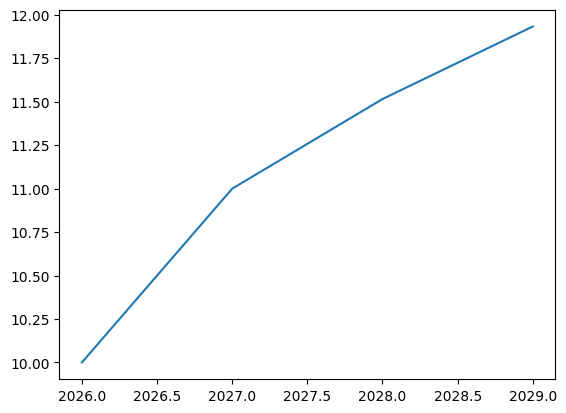

In [113]:
plt.plot(years, offset_base_cost_gbp_per_ton)

we don't need to do anything with years and carbon costs as they are already numpy arrays

now we have some data, lets merge it all togehter. In this methodology we don't have one main dataframe, but a numpy array for each column

In [114]:
fuel_keys, vehicle_keys, years, offset_base_cost_gbp_per_ton, emissions_tons_per_kwh, power_kwh

(array(['diesel', 'petrol'], dtype=object),
 array(['tractor', 'lawnmower', 'generator'], dtype=object),
 array([2026, 2027, 2028, 2029]),
 array([10.        , 11.        , 11.51571657, 11.93318204]),
 array([0.35, 0.25]),
 array([[9000.,   nan],
        [  nan,  450.],
        [2300., 1100.]]))

now we do the calculations

In [115]:
emissions_tons_per_year = emissions_tons_per_kwh * power_kwh
emissions_tons_per_year

array([[3150. ,    nan],
       [   nan,  112.5],
       [ 805. ,  275. ]])

this next one creates a 3D matrix (3,2,4) with dimensions vehicle_keys, fuel_keys, year. 

In [ ]:
offset_cost_gbp_per_year = offset_base_cost_gbp_per_ton * emissions_tons_per_year[:,:,np.newaxis] #here the new axis is created on the end with np.newaxis
offset_cost_gbp_per_year.shape


(3, 2, 4)

to get say the 2D slice of values from the year 2027 we do

In [150]:
offset_cost_gbp_per_year[:,:,np.where(years==2027)[0][0]]

array([[34650. ,     nan],
       [    nan,  1237.5],
       [ 8855. ,  3025. ]])

say we want to extract from this the cost over time split per vehicle type. This is summing together the two types of generator. Because we have nans telling numpy there are gaps in our dataset, we use `nansum` which gracefully handles gaps (essentially inner join)

In [158]:
offset_cost_gbp_per_year_by_vehicle = np.nansum(offset_cost_gbp_per_year, axis=1)
offset_cost_gbp_per_year_by_vehicle

array([[31500.        , 34650.        , 36274.50718451, 37589.52344154],
       [ 1125.        ,  1237.5       ,  1295.51811373,  1342.48298005],
       [10800.        , 11880.        , 12436.97389183, 12887.83660853]])

and then plot

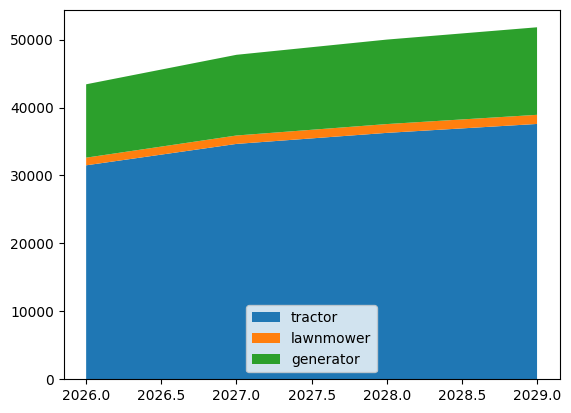

In [160]:
plt.stackplot(years,
              offset_cost_gbp_per_year_by_vehicle,
              labels=vehicle_keys)
plt.legend()